<a href="https://colab.research.google.com/github/saroo1999/Diabetes/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap lime scikit-learn pandas matplotlib seaborn --quiet
print('✅ All libraries installed successfully!')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries installed successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(7)
shap.initjs()
print('✅ Libraries imported!')

✅ Libraries imported!


In [3]:
np.random.seed(7)
n = 768

pregnancies        = np.random.randint(0, 17, n)
glucose            = np.random.randint(44, 199, n)
blood_pressure     = np.random.randint(24, 122, n)
skin_thickness     = np.random.randint(7, 99, n)
insulin            = np.random.randint(14, 846, n)
bmi                = np.round(np.random.uniform(18.2, 67.1, n), 1)
diabetes_pedigree  = np.round(np.random.uniform(0.078, 2.42, n), 3)
age                = np.random.randint(21, 81, n)

risk = (
    0.04 * (glucose - 120) +
    0.05 * (bmi - 30) +
    0.03 * (age - 40) +
    0.10 * pregnancies +
    0.50 * diabetes_pedigree +
   -0.01 * blood_pressure
)
prob    = 1 / (1 + np.exp(-risk))
outcome = (np.random.uniform(0, 1, n) < prob).astype(int)

df = pd.DataFrame({
    'Pregnancies'             : pregnancies,
    'Glucose'                 : glucose,
    'BloodPressure'           : blood_pressure,
    'SkinThickness'           : skin_thickness,
    'Insulin'                 : insulin,
    'BMI'                     : bmi,
    'DiabetesPedigreeFunction': diabetes_pedigree,
    'Age'                     : age,
    'Outcome'                 : outcome
})

print(f'Dataset shape: {df.shape}')
print(f'Diabetic (1): {outcome.sum()}  |  Non-Diabetic (0): {(outcome==0).sum()}')
df.head(10)

Dataset shape: (768, 9)
Diabetic (1): 572  |  Non-Diabetic (0): 196


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,15,65,67,7,443,20.4,2.276,65,1
1,4,46,62,17,69,29.7,2.307,77,0
2,3,193,117,93,699,42.1,1.781,25,1
3,7,73,40,11,151,42.6,1.194,33,0
4,14,48,31,37,375,26.6,1.328,60,1
5,8,154,71,53,529,40.4,2.230,30,1
6,14,193,103,65,559,39.8,1.802,76,1
7,10,104,56,14,369,57.8,1.832,25,1
8,8,89,108,96,37,63.3,2.279,77,1
9,7,93,99,56,760,65.0,0.951,47,1


In [4]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

=== Statistical Summary ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,8.15,120.36,70.26,53.64,446.45,43.03,1.27,51.04,0.74
std,4.99,43.82,28.67,27.06,241.68,13.79,0.69,16.96,0.44
min,0.00,44.00,24.00,7.00,15.00,18.30,0.08,21.00,0.00
25%,4.00,85.00,45.00,29.00,240.75,30.70,0.67,37.00,0.00
50%,8.00,118.00,70.00,54.00,455.50,43.55,1.24,50.00,1.00
75%,12.00,158.00,95.00,78.00,647.25,54.90,1.89,66.25,1.00
max,16.00,198.00,121.00,98.00,844.00,67.10,2.41,80.00,1.00


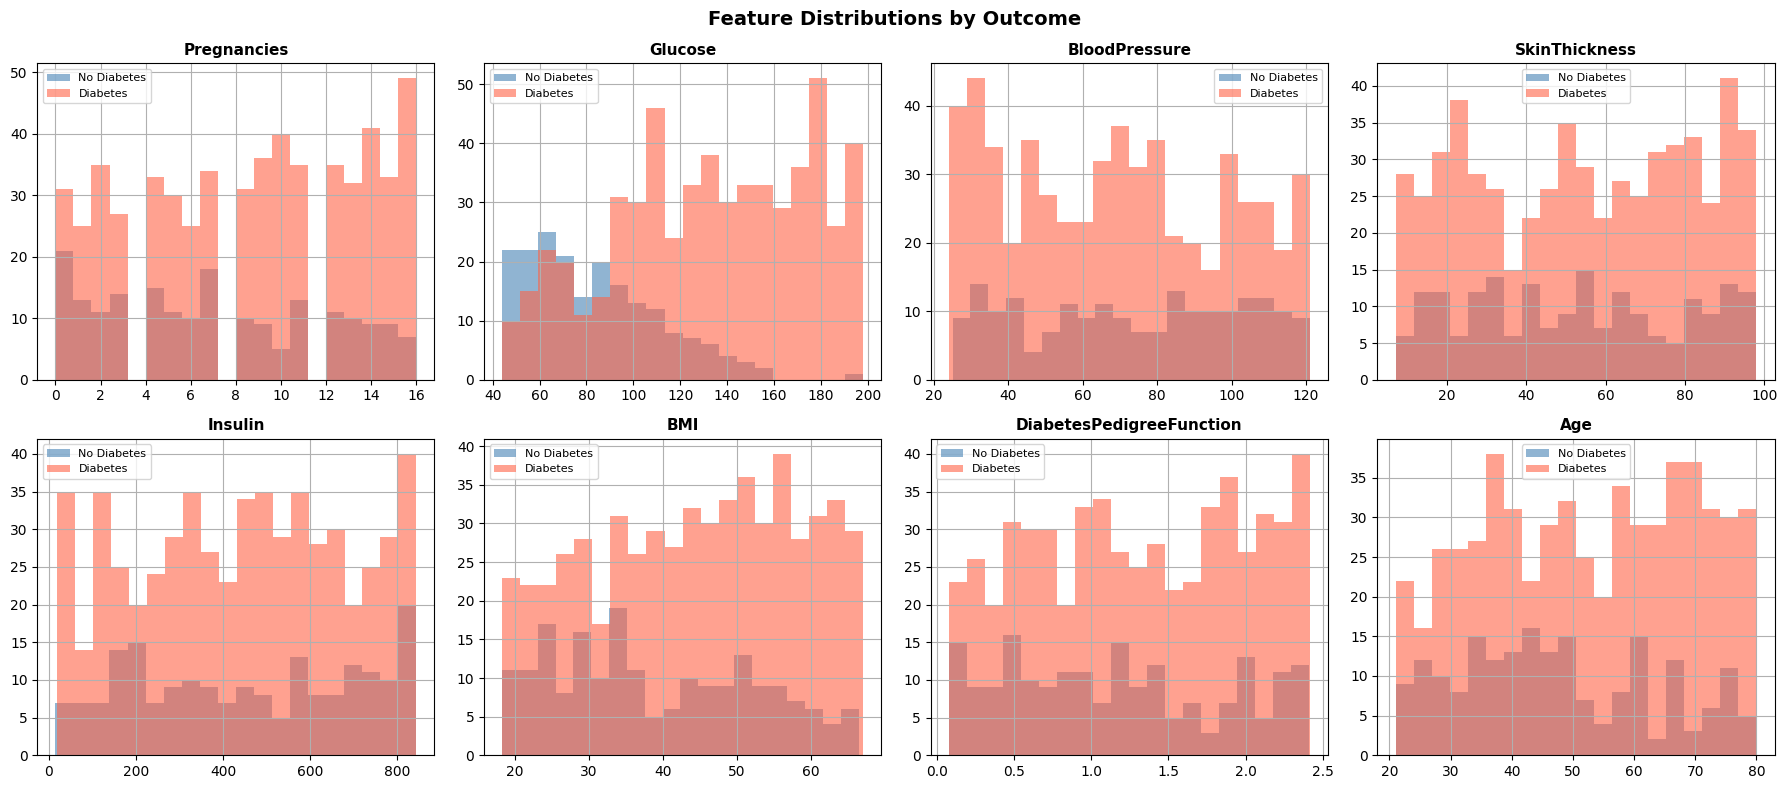

✅ Plot saved as feature_distributions.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
feature_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigreeFunction','Age']

for ax, feat in zip(axes.flatten(), feature_names):
    df[df['Outcome']==0][feat].hist(ax=ax, alpha=0.6, color='steelblue', label='No Diabetes', bins=20)
    df[df['Outcome']==1][feat].hist(ax=ax, alpha=0.6, color='tomato',    label='Diabetes',    bins=20)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as feature_distributions.png')

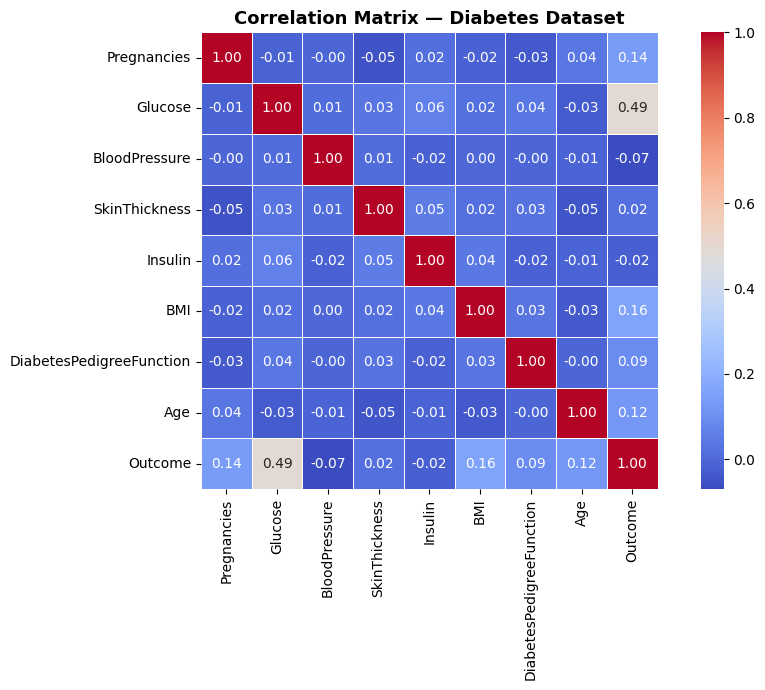

✅ Heatmap saved


In [6]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Diabetes Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved')

In [8]:
X = df[feature_names].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=7)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test  size : {X_test.shape[0]}  samples')
print(f'\n✅ Model Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Diabetes','Diabetes']))

Train size : 614 samples
Test  size : 154  samples

✅ Model Accuracy: 0.7987 (79.87%)

=== Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.67      0.41      0.51        39
    Diabetes       0.82      0.93      0.87       115

    accuracy                           0.80       154
   macro avg       0.74      0.67      0.69       154
weighted avg       0.78      0.80      0.78       154



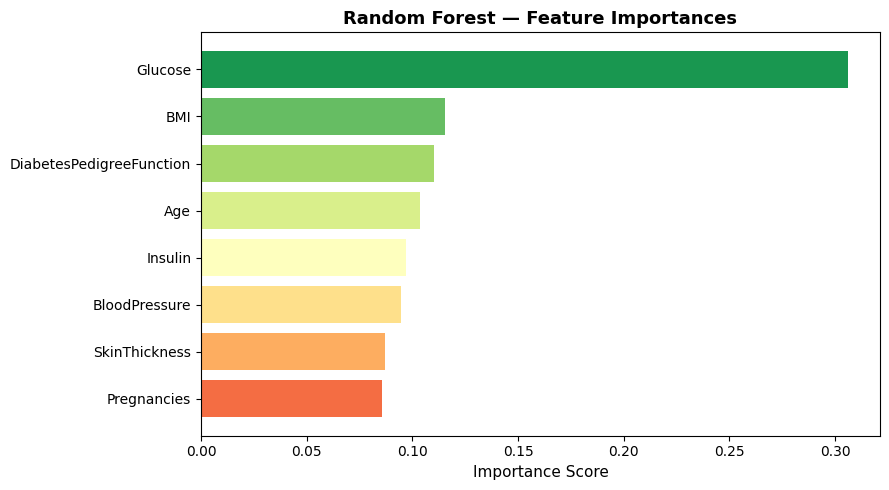

✅ Top feature: Glucose


In [9]:
importances = model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=11)
plt.title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Top feature:', fi_df.iloc[-1]['Feature'])

SHAP values shape: (154, 8, 2)
Test set size    : (154, 8)


<Figure size 1000x600 with 0 Axes>

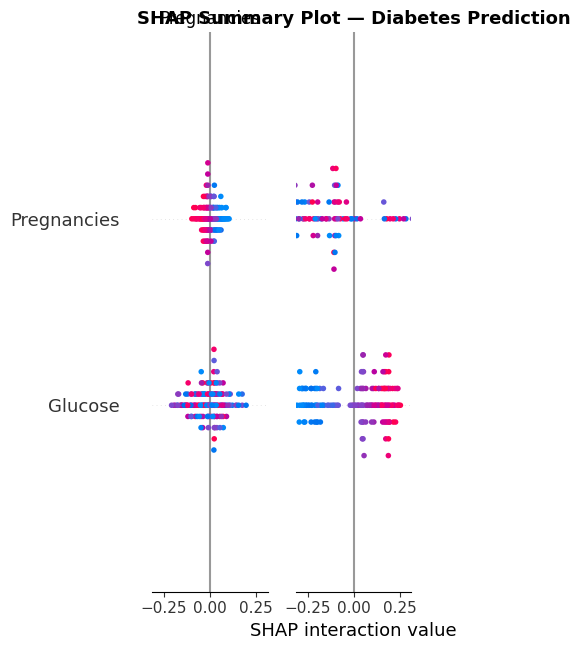

✅ SHAP summary plot saved


In [10]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [class0, class1]
shap_vals_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP values shape: {shap_vals_pos.shape}')
print(f'Test set size    : {X_test.shape}')

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_pos, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot — Diabetes Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP summary plot saved')

<Figure size 900x500 with 0 Axes>

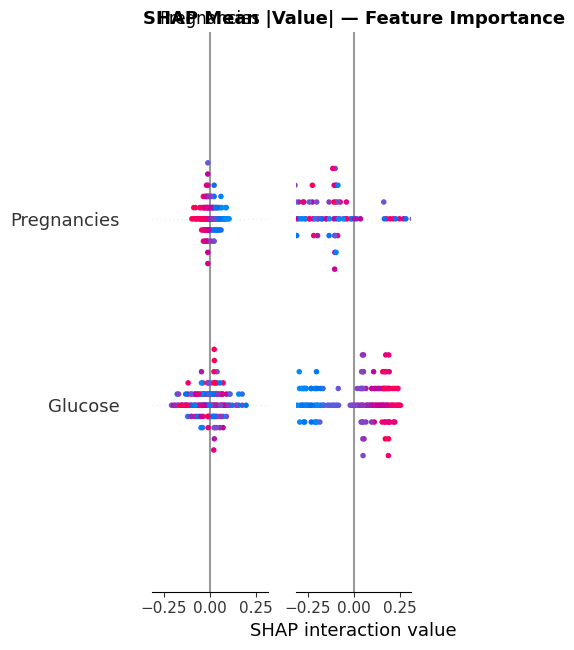

✅ SHAP bar plot saved


In [11]:
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_vals_pos, X_test, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('SHAP Mean |Value| — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP bar plot saved')

In [12]:
patient_idx = 0   # ← change this (0 to 153)

patient     = X_test[patient_idx]
true_label  = y_test[patient_idx]
pred_prob   = model.predict_proba([patient])[0][1]
pred_label  = model.predict([patient])[0]

print(f'Patient #{patient_idx}')
print(f'  True label : {"Diabetic" if true_label==1 else "Not Diabetic"}')
print(f'  Predicted  : {"Diabetic" if pred_label==1 else "Not Diabetic"} (prob={pred_prob:.4f})')
print()
for name, val in zip(feature_names, patient):
    print(f'  {name:<28}: {val}')

# SHAP waterfall / force plot
shap_val_patient = shap_vals_pos[patient_idx]

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_val_patient,
        base_values   = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data          = patient,
        feature_names = feature_names
    ),
    show=False
)
plt.title(f'SHAP Waterfall — Patient #{patient_idx}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_patient{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP waterfall saved')


Patient #0
  True label : Not Diabetic
  Predicted  : Not Diabetic (prob=0.4000)

  Pregnancies                 : 10.0
  Glucose                     : 73.0
  BloodPressure               : 88.0
  SkinThickness               : 62.0
  Insulin                     : 698.0
  BMI                         : 28.5
  DiabetesPedigreeFunction    : 1.836
  Age                         : 27.0


ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (8, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [16]:
# Change 'Glucose' to any feature name to explore
feature_to_plot = 'Glucose'

plt.figure(figsize=(9, 5))
shap.dependence_plot(
    feature_to_plot,
    shap_vals_pos,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title(f'SHAP Dependence Plot — {feature_to_plot}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dependence plot saved')

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 15


🩺 LIME Explanation for Patient #0
  True label : Not Diabetic
  Predicted  : Not Diabetic

LIME feature contributions (positive = pushes toward Diabetic):
  ▼ Glucose <= 86.00                         : -0.3361
  ▼ BMI <= 31.23                             : -0.0768
  ▼ Age <= 37.00                             : -0.0671
  ▼ Insulin > 649.75                         : -0.0343
  ▲ 1.22 < DiabetesPedigreeFunction <= 1.85  : +0.0341
  ▲ 8.00 < Pregnancies <= 13.00              : +0.0217
  ▲ 53.00 < SkinThickness <= 78.00           : +0.0042
  ▼ 71.00 < BloodPressure <= 97.00           : -0.0006


<Figure size 900x500 with 0 Axes>

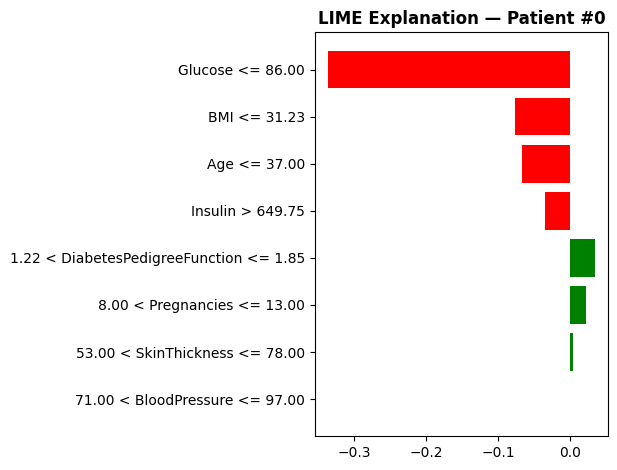

✅ LIME plot saved


In [14]:
patient_idx = 0   # ← change this (0 to 153)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = feature_names,
    class_names    = ['No Diabetes', 'Diabetes'],
    mode           = 'classification',
    random_state   = 7
)

lime_exp = lime_explainer.explain_instance(
    data_row       = X_test[patient_idx],
    predict_fn     = model.predict_proba,
    num_features   = 8
)

print(f'\n🩺 LIME Explanation for Patient #{patient_idx}')
print(f'  True label : {"Diabetic" if y_test[patient_idx]==1 else "Not Diabetic"}')
print(f'  Predicted  : {"Diabetic" if model.predict([X_test[patient_idx]])[0]==1 else "Not Diabetic"}')
print()
print('LIME feature contributions (positive = pushes toward Diabetic):')
for feat, weight in lime_exp.as_list():
    direction = '▲' if weight > 0 else '▼'
    print(f'  {direction} {feat:<40} : {weight:+.4f}')

fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Explanation — Patient #{patient_idx}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'lime_patient{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ LIME plot saved')


🩺 LIME Explanation for Patient #0
  True label : Not Diabetic
  Predicted  : Not Diabetic

LIME feature contributions (positive = pushes toward Diabetic):
  ▼ Glucose <= 86.00                         : -0.3361
  ▼ BMI <= 31.23                             : -0.0768
  ▼ Age <= 37.00                             : -0.0671
  ▼ Insulin > 649.75                         : -0.0343
  ▲ 1.22 < DiabetesPedigreeFunction <= 1.85  : +0.0341
  ▲ 8.00 < Pregnancies <= 13.00              : +0.0217
  ▲ 53.00 < SkinThickness <= 78.00           : +0.0042
  ▼ 71.00 < BloodPressure <= 97.00           : -0.0006


<Figure size 900x500 with 0 Axes>

<Figure size 900x500 with 0 Axes>

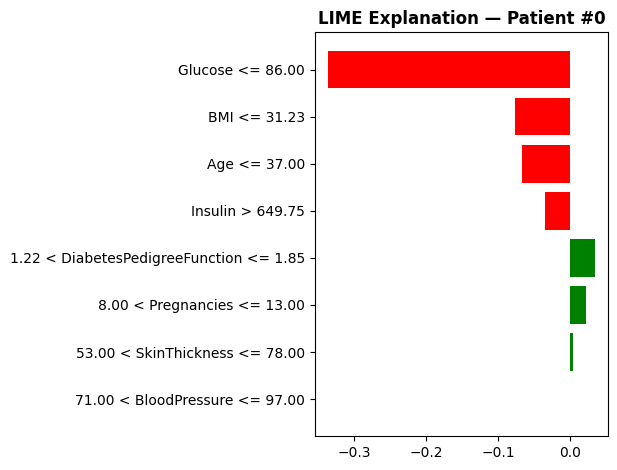

✅ LIME plot saved


In [17]:
patient_idx = 0   # ← change this (0 to 153)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = feature_names,
    class_names    = ['No Diabetes', 'Diabetes'],
    mode           = 'classification',
    random_state   = 7
)

lime_exp = lime_explainer.explain_instance(
    data_row       = X_test[patient_idx],
    predict_fn     = model.predict_proba,
    num_features   = 8
)

print(f'\n🩺 LIME Explanation for Patient #{patient_idx}')
print(f'  True label : {"Diabetic" if y_test[patient_idx]==1 else "Not Diabetic"}')
print(f'  Predicted  : {"Diabetic" if model.predict([X_test[patient_idx]])[0]==1 else "Not Diabetic"}')
print()
print('LIME feature contributions (positive = pushes toward Diabetic):')
for feat, weight in lime_exp.as_list():
    direction = '▲' if weight > 0 else '▼'
    print(f'  {direction} {feat:<40} : {weight:+.4f}')

fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Explanation — Patient #{patient_idx}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'lime_patient{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ LIME plot saved')

In [19]:
patient_idx = 0   # ← change this

# --- SHAP values ---
shap_val    = shap_vals_pos[patient_idx]
shap_series = pd.Series(shap_val, index=feature_names).sort_values(key=abs, ascending=False)

# --- LIME values ---
lime_exp2   = lime_explainer.explain_instance(
    X_test[patient_idx], model.predict_proba, num_features=8
)
lime_dict   = dict(lime_exp2.as_list())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP
colors_shap = ['tomato' if v > 0 else 'steelblue' for v in shap_series.values]
axes[0].barh(shap_series.index[::-1], shap_series.values[::-1], color=colors_shap[::-1])
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title(f'SHAP — Patient #{patient_idx}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SHAP Value')

# LIME
lime_vals   = list(lime_dict.values())
lime_feats  = list(lime_dict.keys())
colors_lime = ['tomato' if v > 0 else 'steelblue' for v in lime_vals]
axes[1].barh(lime_feats[::-1], lime_vals[::-1], color=colors_lime[::-1])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title(f'LIME — Patient #{patient_idx}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('LIME Weight')

plt.suptitle('SHAP vs LIME Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_vs_lime_patient{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison plot saved')

ValueError: Data must be 1-dimensional, got ndarray of shape (8, 2) instead

In [20]:
probs       = model.predict_proba(X_test)[:, 1]
uncertainty = np.abs(probs - 0.5)
hardest_idx = np.argmin(uncertainty)

print(f'Most uncertain patient index : {hardest_idx}')
print(f'Predicted probability (Diabetic): {probs[hardest_idx]:.4f}')
print(f'True label: {"Diabetic" if y_test[hardest_idx]==1 else "Not Diabetic"}')

# YOUR CODE HERE
# Copy Steps 10 and 12, replace patient_idx with hardest_idx
# Write a markdown cell below with your analysis

Most uncertain patient index : 12
Predicted probability (Diabetic): 0.5000
True label: Diabetic
